# Assignment 2

To find all faces belonging to a vertex, we need to iterate trough the structure as follows:

1. From vertex, get one of its outgoing half-edges
2. Get face of current half-edge
3. Assign to the current half-edge, the opposite half-edge of current half-edge
4. Assign to the current half-edge, the next half-edge of the current half-edge
5. Loop back to 2 until current half-edge is the outgoing half-edge of our vertex

# Assignment 3

## a)
$K_0 = \{v_0,v_1,v_2,v_3,v_4,v_5\}$

$K_0 = \{(v_0​,v_1),(v_0,v_2),(v_0,v_3),(v_0,v_4),(v_0,v_5),(v_1​,v_2​),(v_2​,v_3​​),(v_3​,v_4​),(v_4​,v_5​​),(v_5,v_1)\}$

$K_2 = \{(v_0​,v_1​,v_2),(v_0​,v_2​,v_3),(v_0​,v_3​,v_4​),(v_0​,v_4​,v_5​),(v_0​,v_5​,v_1​)\}$

- All 2-Simplex are orientated positive
- All 1-Simplex are orientated like the 2-Simplex, which occurs first
- All 0-Simplex are independent of orientation


## b)

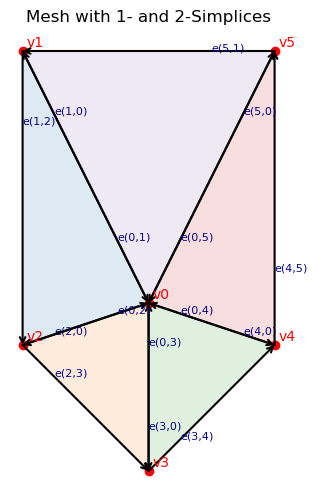

In [5]:
import matplotlib.pyplot as plt
import numpy as np

V = [
    np.array([0.0, 0.0]),
    np.array([-1.5, 3.0]),
    np.array([-1.5, -0.5]),
    np.array([0.0, -2.0]),
    np.array([1.5, -0.5]),
    np.array([1.5, 3.0])
]
F = [
    [0, 1, 2],
    [0, 2, 3],
    [0, 3, 4],
    [0, 4, 5],
    [0, 5, 1]
]
edges = set()
for f in F:
    edges.add((f[0], f[1]))
    edges.add((f[1], f[2]))
    edges.add((f[2], f[0]))
edges = list(edges)

fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect('equal')
ax.set_title("Mesh with 1- and 2-Simplices")

for i, (a,b,c) in enumerate(F):
    tri = np.array([V[a], V[b], V[c], V[a]])
    ax.fill(tri[:,0], tri[:,1], alpha=0.15, label=f"f{i}")

for (a,b) in edges:
    p1, p2 = V[a], V[b]
    ax.annotate("",
                xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="->", color='black', lw=1.5, shrinkA=0, shrinkB=0))
                
    mid = (0.75*p1 + 0.25*p2)
    ax.text(mid[0], mid[1], f"e({a},{b})", fontsize=8, color='darkblue')

for i, p in enumerate(V):
    ax.plot(p[0], p[1], 'ro')
    ax.text(p[0]+0.05, p[1]+0.05, f"v{i}", fontsize=10, color='red')

ax.axis('off')
plt.show()


## c)

In [9]:
import numpy as np

# K0: Vertices
K0 = list(range(6))

# K1: Edges
K1 = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,1),(0,2),(0,3),(0,4),(0,5)]

# K2: faces
K2 = [(0,1,2),(0,2,3),(0,3,4),(0,4,5),(0,5,1)]

n0 = len(K0)
n1 = len(K1)
n2 = len(K2)

# ∂1
d1 = np.zeros((n0, n1), dtype=int)
for j,(a,b) in enumerate(K1):
    d1[a, j] = -1
    d1[b, j] =  1

edge_index = {e:i for i,e in enumerate(K1)}

# ∂2
d2 = np.zeros((n1, n2), dtype=int)
for j,(a,b,c) in enumerate(K2):
    terms = [((b,c), 1), ((a,c), -1), ((a,b), 1)]
    for (u,v), coef in terms:
        if (u,v) in edge_index:
            d2[edge_index[(u,v)], j] += coef
        elif (v,u) in edge_index:
            d2[edge_index[(v,u)], j] -= coef

# np.set_printoptions(linewidth=120)
print("∂1 (6 x 10) =\n", d1, "\n")
print("∂2 (10 x 5) =\n", d2, "\n")

# Check: ∂1 * ∂2 == 0
prod = d1.dot(d2)
print(prod)

∂1 (6 x 10) =
 [[-1  0  0  0  0  0 -1 -1 -1 -1]
 [ 1 -1  0  0  0  1  0  0  0  0]
 [ 0  1 -1  0  0  0  1  0  0  0]
 [ 0  0  1 -1  0  0  0  1  0  0]
 [ 0  0  0  1 -1  0  0  0  1  0]
 [ 0  0  0  0  1 -1  0  0  0  1]] 

∂2 (10 x 5) =
 [[ 1  0  0  0 -1]
 [ 1  0  0  0  0]
 [ 0  1  0  0  0]
 [ 0  0  1  0  0]
 [ 0  0  0  1  0]
 [ 0  0  0  0  1]
 [-1  1  0  0  0]
 [ 0 -1  1  0  0]
 [ 0  0 -1  1  0]
 [ 0  0  0 -1  1]] 

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


## d)

∂2 * c2 =
 [ 1  1  1  1  0  0  0  0 -1  0]


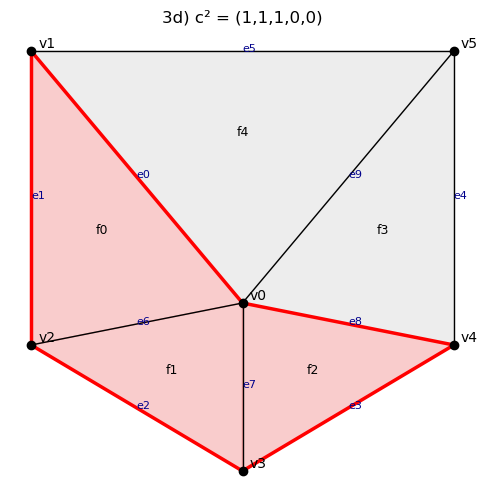

In [18]:
import matplotlib.pyplot as plt

c2 = np.array([1,1,1,0,0])
b_vec = d2.dot(c2)

print("∂2 * c2 =\n", b_vec)

fig, ax = plt.subplots(figsize=(6,6))
ax.set_title("3d) c² = (1,1,1,0,0)")

for j,(a,b,c) in enumerate(K2):
    pts = np.array([V[a], V[b], V[c], V[a]])
    color = 'lightcoral' if c2[j]==1 else 'lightgray'
    ax.fill(pts[:,0], pts[:,1], color=color, alpha=0.4)
    centroid = np.mean(pts[:-1,:], axis=0)
    ax.text(centroid[0], centroid[1], f"f{j}", fontsize=9, ha='center')

for i,(a,b) in enumerate(K1):
    p1,p2 = V[a],V[b]
    col = 'red' if b_vec[i]!=0 else 'black'
    lw  = 2.5 if b_vec[i]!=0 else 1
    ax.plot([p1[0],p2[0]],[p1[1],p2[1]], color=col, lw=lw)
    mid = (p1+p2)/2
    ax.text(mid[0], mid[1], f"e{i}", fontsize=8, color='darkblue')

for i,p in V.items():
    ax.plot(p[0],p[1],'ko')
    ax.text(p[0]+0.05,p[1]+0.05,f"v{i}",color='black')

ax.axis('off')
plt.show()
